# Regularized RBSDE midpoint profiles

This notebook computes only the regularized reflected-BSDE approximation for an American put. The observation count is fixed at $N_{\mathrm{obs}}=2^{10}$, and the midpoint values $Y_{T/2}^{\varepsilon}$ are compared node by node with the CRR reference on the same fine binomial tree. The regularization width is

$$\varepsilon = C\,\Delta t_{\mathrm{obs}}^{\alpha}.$$

Only midpoint nodes whose spot prices lie in $[50,150]$ are plotted. Distinct line and marker styles separate the parameter choices.

In [1]:
from dataclasses import dataclass
from functools import lru_cache
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.linestyle": ":",
})

## Configuration

`N_fine` is the resolution of the shared CRR tree. `N_OBS` is the sparse RBSDE observation count and is fixed to the requested value.

In [2]:
@dataclass(frozen=True)
class ModelParams:
    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0
    r: float = 0.02
    sigma: float = 0.2
    N_fine: int = 2**15


model = ModelParams()
N_OBS = 2**10
BISECTION_TOL = 1e-8
SPOT_MIN = 50.0
SPOT_MAX = 150.0
SOLUTION_LINE_STYLES = ("-", "--", "-.", ":", (0, (3, 1, 1, 1)))
SOLUTION_MARKERS = ("o", "s", "^", "D", "v")

if model.N_fine % N_OBS != 0:
    raise ValueError("N_fine must be divisible by N_OBS.")
if N_OBS % 2 != 0:
    raise ValueError("N_OBS must be even so that T/2 is observed exactly.")

## Binomial and regularization helpers

In [3]:
@lru_cache(maxsize=None)
def binomial_probabilities(m: int, q: float) -> np.ndarray:
    """Probability mass for the number of up moves over m fine steps."""
    ell = np.arange(m + 1)
    log_probs = (
        gammaln(m + 1)
        - gammaln(ell + 1)
        - gammaln(m - ell + 1)
        + ell * np.log(q)
        + (m - ell) * np.log1p(-q)
    )
    return np.exp(log_probs - logsumexp(log_probs))


def multi_step_conditional_expectation(
    Y_next: np.ndarray, m: int, q: float
) -> np.ndarray:
    """Compute E[Y_next | current node] across m skipped fine steps."""
    return np.correlate(Y_next, binomial_probabilities(m, q), mode="valid")


def stock_values(model: ModelParams, n: int, u: float, d: float) -> np.ndarray:
    """Spot prices at every node of CRR level n, ordered from down to up."""
    j = np.arange(n + 1)
    return model.S0 * u**j * d ** (n - j)


def smooth_cutoff(x: np.ndarray) -> np.ndarray:
    """Smooth switch equal to 1 for x <= 0 and 0 for x >= 1."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    out[x <= 0.0] = 1.0
    transition = (x > 0.0) & (x < 1.0)
    exp_left = np.exp(-1.0 / x[transition])
    exp_right = np.exp(-1.0 / (1.0 - x[transition]))
    out[transition] = exp_right / (exp_left + exp_right)
    return out


def regularized_residual(
    Y: np.ndarray,
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    model: ModelParams,
    dt_obs: float,
    epsilon: float,
) -> np.ndarray:
    """Residual of the implicit regularized RBSDE update."""
    activation = smooth_cutoff((Y - obstacle) / epsilon)
    obstacle_correction = model.r * model.K * (S <= model.K) * activation
    generator = -model.r * Y + obstacle_correction
    return Y - base - dt_obs * generator


def regularized_bisection_update(
    base: np.ndarray,
    S: np.ndarray,
    obstacle: np.ndarray,
    model: ModelParams,
    dt_obs: float,
    epsilon: float,
    tol: float = BISECTION_TOL,
    max_iter: int = 80,
) -> np.ndarray:
    """Solve the nodewise implicit equation by bisection."""
    lo = np.zeros_like(base) - tol
    hi = np.maximum(np.full_like(base, model.K) + tol, base + model.K + 10.0)

    for _ in range(max_iter):
        midpoint = 0.5 * (lo + hi)
        residual = regularized_residual(
            midpoint, base, S, obstacle, model, dt_obs, epsilon
        )
        lo = np.where(residual <= 0.0, midpoint, lo)
        hi = np.where(residual > 0.0, midpoint, hi)
        if np.max(hi - lo) < tol:
            break

    return 0.5 * (lo + hi)

## Midpoint solvers

Only the backward slices needed to reach $T/2$ are computed. For each parameter choice, the mean relative error (`MRE`) is the probability-weighted mean absolute relative error over all midpoint nodes, multiplied by 100:

$$\mathrm{MRE}=100\,\frac{\sum_j w_j\,|Y_j^{\varepsilon}-Y_j^{\mathrm{CRR}}|/|Y_j^{\mathrm{CRR}}|}{\sum_j w_j}.$$

Here $w_j$ is the midpoint CRR binomial probability. The spot restriction $[50,150]$ is used only for plotting. Each legend reports `MRE` rounded to three decimal places.

In [4]:
def regularized_rbsde_midpoint(
    model: ModelParams,
    epsilon_constant: float,
    epsilon_power: float,
    N_obs: int = N_OBS,
) -> dict:
    """Return Y^epsilon and spot prices at every tree node at T/2."""
    if N_obs != N_OBS:
        raise ValueError(f"This experiment fixes N_obs at {N_OBS}.")

    N = model.N_fine
    m = N // N_obs
    dt_fine = model.T / N
    dt_obs = model.T / N_obs
    epsilon = epsilon_constant * dt_obs**epsilon_power

    u = np.exp(model.sigma * np.sqrt(dt_fine))
    d = 1.0 / u
    q = (np.exp(model.r * dt_fine) - d) / (u - d)
    if not 0.0 < q < 1.0:
        raise ValueError(f"Invalid risk-neutral probability q={q:.6f}.")

    S_terminal = stock_values(model, N, u, d)
    Y = np.maximum(model.K - S_terminal, 0.0)
    midpoint_observation = N_obs // 2

    start = time.perf_counter()
    for k in range(N_obs - 1, midpoint_observation - 1, -1):
        n_now = k * m
        base = multi_step_conditional_expectation(Y, m, q)
        S_now = stock_values(model, n_now, u, d)
        obstacle = np.maximum(model.K - S_now, 0.0)
        Y = regularized_bisection_update(
            base, S_now, obstacle, model, dt_obs, epsilon
        )

    elapsed = time.perf_counter() - start
    print(
        f"C={epsilon_constant:g}, alpha={epsilon_power:g}, "
        f"epsilon={epsilon:.8g}, midpoint nodes={Y.size}, time={elapsed:.2f}s"
    )
    return {
        "spot": S_now,
        "Y_epsilon": Y,
        "epsilon": epsilon,
        "epsilon_constant": epsilon_constant,
        "epsilon_power": epsilon_power,
    }


def crr_american_put_midpoint(model: ModelParams) -> dict:
    """CRR American-put values at every node at T/2."""
    N = model.N_fine
    n_mid = N // 2
    dt = model.T / N
    u = np.exp(model.sigma * np.sqrt(dt))
    d = 1.0 / u
    q = (np.exp(model.r * dt) - d) / (u - d)
    discount = np.exp(-model.r * dt)

    S = stock_values(model, N, u, d)
    V = np.maximum(model.K - S, 0.0)

    start = time.perf_counter()
    for n in range(N - 1, n_mid - 1, -1):
        V = discount * ((1.0 - q) * V[:-1] + q * V[1:])
        S = stock_values(model, n, u, d)
        V = np.maximum(V, np.maximum(model.K - S, 0.0))

    weights = binomial_probabilities(n_mid, q)
    print(f"CRR reference: midpoint nodes={V.size}, time={time.perf_counter() - start:.2f}s")
    return {"spot": S, "value": V, "weights": weights}


reference = crr_american_put_midpoint(model)
solution_cache: dict[tuple[float, float], dict] = {}


def midpoint_solution(epsilon_constant: float, epsilon_power: float) -> dict:
    """Compute each parameter pair once and reuse the shared sweep point."""
    key = (float(epsilon_constant), float(epsilon_power))
    if key not in solution_cache:
        solution_cache[key] = regularized_rbsde_midpoint(
            model, epsilon_constant=key[0], epsilon_power=key[1]
        )
        np.testing.assert_allclose(
            solution_cache[key]["spot"], reference["spot"], rtol=1e-13, atol=0.0
        )
    return solution_cache[key]


def mean_relative_error(
    approximation: np.ndarray,
    benchmark: np.ndarray,
    weights: np.ndarray,
) -> float:
    """Probability-weighted mean absolute relative error over all nodes."""
    if not (approximation.shape == benchmark.shape == weights.shape):
        raise ValueError("Approximation, benchmark, and weights must align.")
    total_weight = np.sum(weights)
    if total_weight <= 0.0:
        raise ValueError("The midpoint nodes have zero total probability.")

    absolute_benchmark = np.abs(benchmark)
    weighted_absolute_error = weights * np.abs(approximation - benchmark)
    contributions = np.zeros_like(benchmark, dtype=float)
    np.divide(
        weighted_absolute_error,
        absolute_benchmark,
        out=contributions,
        where=absolute_benchmark > 0.0,
    )

    # A zero benchmark and zero weighted error contributes zero. If a
    # positive-probability node has nonzero error against a zero benchmark,
    # its relative error is infinite.
    undefined = (absolute_benchmark == 0.0) & (weighted_absolute_error > 0.0)
    if np.any(undefined):
        return float("inf")
    return float(np.sum(contributions) / total_weight)

CRR reference: midpoint nodes=16385, time=7.37s


## Vary the epsilon power

Here $C=0.5$ is fixed and $\alpha\in\{0.2,0.375,0.5,0.75,1\}$.

In [5]:
fixed_constant = 0.5
epsilon_powers = (0.2, 0.375, 0.5, 0.75, 1.0)
power_results = {
    alpha: midpoint_solution(fixed_constant, alpha) for alpha in epsilon_powers
}

reference_mask = (reference["spot"] >= SPOT_MIN) & (reference["spot"] <= SPOT_MAX)
power_mean_relative_errors = {
    alpha: mean_relative_error(
        result["Y_epsilon"],
        reference["value"],
        reference["weights"],
    )
    for alpha, result in power_results.items()
}
print("\nMean relative error (MRE) vs. CRR at T/2")
print(f"All midpoint nodes, C={fixed_constant:g}")
for alpha, error in power_mean_relative_errors.items():
    print(f"alpha={alpha:g}: {100 * error:.8f}%")

C=0.5, alpha=0.2, epsilon=0.125, midpoint nodes=16385, time=7.41s


C=0.5, alpha=0.375, epsilon=0.037162722, midpoint nodes=16385, time=7.34s


C=0.5, alpha=0.5, epsilon=0.015625, midpoint nodes=16385, time=7.24s


C=0.5, alpha=0.75, epsilon=0.0027621359, midpoint nodes=16385, time=7.49s


C=0.5, alpha=1, epsilon=0.00048828125, midpoint nodes=16385, time=7.46s

Mean relative error (MRE) vs. CRR at T/2
All midpoint nodes, C=0.5
alpha=0.2: 0.32266709%
alpha=0.375: 0.11572317%
alpha=0.5: 0.05129794%
alpha=0.75: 0.00625667%
alpha=1: 0.00315378%


## Vary the epsilon constant

Here $\alpha=0.375$ is fixed and $C\in\{0.1,0.2,0.5,1,2\}$.

C=0.1, alpha=0.375, epsilon=0.0074325445, midpoint nodes=16385, time=7.34s


C=0.2, alpha=0.375, epsilon=0.014865089, midpoint nodes=16385, time=7.46s


C=1, alpha=0.375, epsilon=0.074325445, midpoint nodes=16385, time=7.66s


C=2, alpha=0.375, epsilon=0.14865089, midpoint nodes=16385, time=7.65s

Mean relative error (MRE) vs. CRR at T/2
All midpoint nodes, alpha=0.375
C=0.1: 0.02352776%
C=0.2: 0.04882298%
C=0.5: 0.11572317%
C=1: 0.21098923%
C=2: 0.36998104%


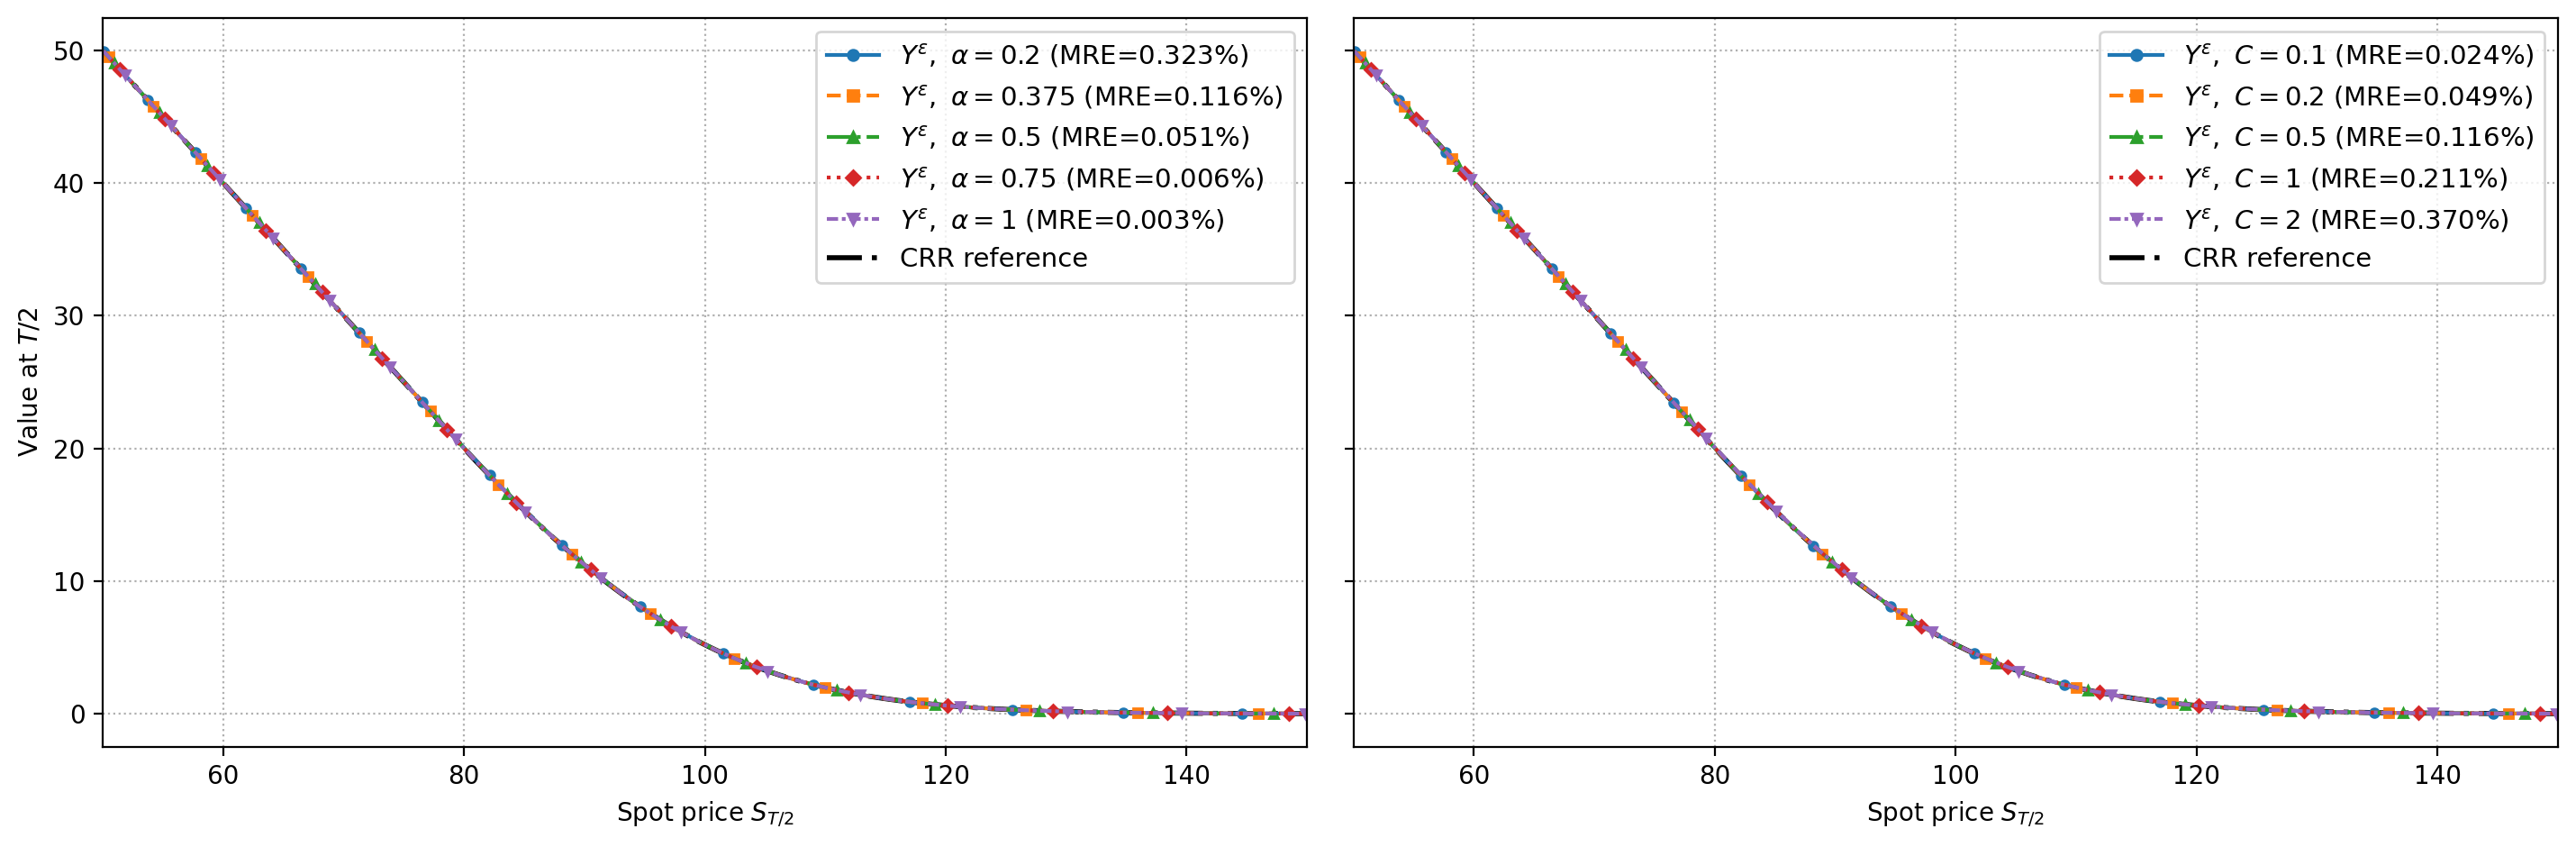

In [6]:
fixed_power = 0.375
epsilon_constants = (0.1, 0.2, 0.5, 1.0, 2.0)
constant_results = {
    constant: midpoint_solution(constant, fixed_power)
    for constant in epsilon_constants
}

reference_mask = (reference["spot"] >= SPOT_MIN) & (reference["spot"] <= SPOT_MAX)
constant_mean_relative_errors = {
    constant: mean_relative_error(
        result["Y_epsilon"],
        reference["value"],
        reference["weights"],
    )
    for constant, result in constant_results.items()
}
print("\nMean relative error (MRE) vs. CRR at T/2")
print(f"All midpoint nodes, alpha={fixed_power:g}")
for constant, error in constant_mean_relative_errors.items():
    print(f"C={constant:g}: {100 * error:.8f}%")

fig_horizontal, (ax_power, ax_constant) = plt.subplots(
    1, 2, figsize=(14.4, 4.8), sharey=True
)

for i, (alpha, result) in enumerate(power_results.items()):
    mask = (result["spot"] >= SPOT_MIN) & (result["spot"] <= SPOT_MAX)
    ax_power.plot(
        result["spot"][mask],
        result["Y_epsilon"][mask],
        linewidth=1.5,
        linestyle=SOLUTION_LINE_STYLES[i],
        marker=SOLUTION_MARKERS[i],
        markersize=3.5,
        markevery=(4 * i, 32),
        label=(
            fr"$Y^{{\varepsilon}},\ \alpha={alpha:g}$ "
            f"(MRE={100 * power_mean_relative_errors[alpha]:.3f}%)"
        ),
    )
ax_power.plot(
    reference["spot"][reference_mask],
    reference["value"][reference_mask],
    color="black",
    linestyle=(0, (7, 2, 1, 2)),
    linewidth=2.0,
    zorder=1,
    label="CRR reference",
)

for i, (constant, result) in enumerate(constant_results.items()):
    mask = (result["spot"] >= SPOT_MIN) & (result["spot"] <= SPOT_MAX)
    ax_constant.plot(
        result["spot"][mask],
        result["Y_epsilon"][mask],
        linewidth=1.5,
        linestyle=SOLUTION_LINE_STYLES[i],
        marker=SOLUTION_MARKERS[i],
        markersize=3.5,
        markevery=(4 * i, 32),
        label=(
            fr"$Y^{{\varepsilon}},\ C={constant:g}$ "
            f"(MRE={100 * constant_mean_relative_errors[constant]:.3f}%)"
        ),
    )
ax_constant.plot(
    reference["spot"][reference_mask],
    reference["value"][reference_mask],
    color="black",
    linestyle=(0, (7, 2, 1, 2)),
    linewidth=2.0,
    zorder=1,
    label="CRR reference",
)
for axis in (ax_power, ax_constant):
    axis.set_xlim(SPOT_MIN, SPOT_MAX)
    axis.set_xlabel(r"Spot price $S_{T/2}$")
    axis.legend(fontsize=10.5, markerscale=1.2)
ax_power.set_ylabel(r"Value at $T/2$")

fig_horizontal.tight_layout(w_pad=1.5)
plt.show()